### COVID-19 Dataset - EDA & Data Cleaning

#### Goal: To understand the dataset's structure, identify quality issues, fix them with clear reasoning, and export a clean version for visualization
**Dataset Source**: Our World in Data (OWID) - COVID-19 Complete Dataset (https://www.kaggle.com/datasets/shreyaagupta/covid19-data-by-owid)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import zipfile

with zipfile.ZipFile('owid-covid-data.csv.zip', 'r') as z:
    z.extractall('.')
    print("Files extracted:")
    print(z.namelist())

Files extracted:
['owid-covid-data.csv']


#####Phase1 - First Look

In [ ]:
df=pd.read_csv("owid-covid-data.csv")
print("Dataset shape:", df.shape)
print("Column names: ",df.columns.tolist())
print("Row Samples: ",df.head(10))
print("Datatypes: ",df.dtypes)
print("Basic Statistics: ",df.describe())

Dataset shape: (350085, 67)
Column names:  ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'pe

######A lot of data - daily records of many countries. Many columns have missing values(especially ICU, hospital, excess mortality, and later vaccination data). Main metrics: total_cases, new_cases, total_deaths, new_deaths.italicized text

#####Phase2 - Missing Values and handling it

In [ ]:
missing =df.isnull().sum().sort_values(ascending=False)
print(missing.head(30))

missing_pct=(df.isnull().sum()/len(df) *100).round(2).sort_values(ascending=False)
print(missing_pct.head(30))

weekly_icu_admissions                      339880
weekly_icu_admissions_per_million          339880
excess_mortality                           337901
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality_cumulative_per_million    337901
weekly_hosp_admissions                     326832
weekly_hosp_admissions_per_million         326832
icu_patients_per_million                   312470
icu_patients                               312470
hosp_patients_per_million                  311183
hosp_patients                              311183
total_boosters_per_hundred                 302523
total_boosters                             302523
new_vaccinations                           284739
people_fully_vaccinated_per_hundred        277510
people_fully_vaccinated                    277510
new_tests                                  274682
new_tests_per_thousand                     274682
people_vaccinated_per_hundred              274174


In [ ]:
#Handling missing values categorically

#1. New cases, new deaths, new vaccinations - fill with 0
cols1=['new_cases','new_deaths','new_vaccinations','new_tests','weekly_icu_admissions','weekly_hosp_admissions']

for c in cols1:
  if c in df.columns:
    df[c]=df[c].fillna(0)

#2. Cumulative columns - forward fill
cols2 =['total_cases','total_deaths','total_vaccinations','people_vaccinated','people_fully_vaccinated','total_boosters']
for c in cols2:
    if c in df.columns:
        df[c] = df.groupby('iso_code')[c].ffill()

#3. per million/rates  - leave as nan for now

print("Missing Values after filling: ")
print(df.isnull().sum().sort_values(ascending=False).head(15))


Missing Values after filling: 
weekly_icu_admissions_per_million          339880
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative_per_million    337901
weekly_hosp_admissions_per_million         326832
icu_patients_per_million                   312470
icu_patients                               312470
hosp_patients                              311183
hosp_patients_per_million                  311183
total_boosters_per_hundred                 302523
people_fully_vaccinated_per_hundred        277510
new_tests_per_thousand                     274682
people_vaccinated_per_hundred              274174
total_vaccinations_per_hundred             270777
dtype: int64


In [ ]:
# Some countries genuinely stopped reporting or never reported
# Filling with 0 is safer than leaving NaN for visualization
df['total_cases'] = df['total_cases'].fillna(0)
df['total_deaths'] = df['total_deaths'].fillna(0)

# Recalculate CFR — use replace(0, NaN) to avoid division by zero
df['cfr'] = (df['total_deaths'] / df['total_cases'].replace(0, np.nan) * 100).round(2)

# Verify
print(f"total_cases nulls: {df['total_cases'].isna().sum()}")
print(f"total_deaths nulls: {df['total_deaths'].isna().sum()}")
# CFR nulls are expected — countries with 0 cases have no calculable fatality rate
print(f"cfr nulls: {df['cfr'].isna().sum()} (expected — countries with 0 cases)")

total_cases nulls: 0
total_deaths nulls: 0
cfr nulls: 37867 (expected — countries with 0 cases)


#####Phase3 - Duplicates

In [ ]:
print("Duplicate rows: ",df.duplicated().sum())


Duplicate rows:  0


######Since no duplicate rows are there, no requirement of dropping rows

####Phase4 - Data Type Fixes

In [ ]:
print("Before Fixing:")
print(df['date'].dtype)

#covert date to datetime
df['date']=pd.to_datetime(df['date'], errors='coerce', format='mixed')

print("\nAfter fixing:")
print(df['date'].dtype)
print("\nDate range:", df['date'].min(), "to", df['date'].max())

Before Fixing:
object

After fixing:
datetime64[ns]

Date range: 2020-01-01 00:00:00 to 2023-10-24 00:00:00


####Phase5 - Logical Inconsistencies
We check for impossible situations:
- total_cases decreasing over time( should be cumulative)
- total_deaths>total_cases
- Negative new_cases/new_deaths

In [ ]:
#sort by loaction and date
df=df.sort_values(['iso_code','date'])

#1. Fix decreasing cumulative values
cum_cols=['total_cases','total_deaths','total_vaccinations','people_vaccinated','people_fully_vaccinated','total_boosters']
for c in cum_cols:
  if c in df.columns:
    df[c]=df.groupby('iso_code')[c].ffill()

#2. Negative values in new_columns
new_cols=['new_cases','new_deaths','new_vaccinations','new_tests']
for c in new_cols:
  if c in df.columns:
    df[c]=df[c].clip(lower=0) # rmv values <0

#3. handle impossible cases (death = cases)
df.loc[df['total_deaths'] > df['total_cases'], 'total_deaths'] = df['total_cases']
print("After fixing: ",len(df[df['total_deaths'] > df['total_cases']])," impossible cases left.")

After fixing:  0  impossible cases left.


####Phase6 - Outlier Detection and Handling

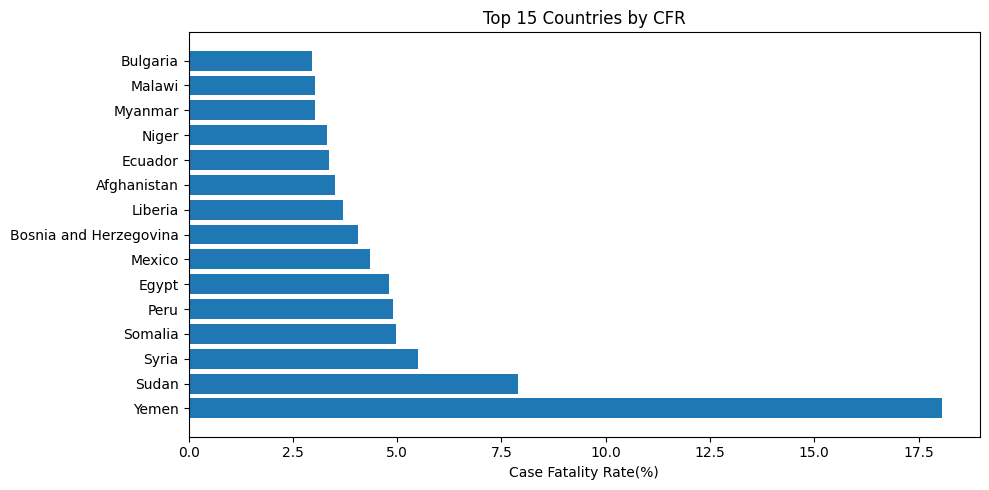

In [ ]:
# calculate CFR
df['cfr']=(df['total_deaths']/ df['total_cases']*100).round(2)

latest_df=df.groupby('location').last().reset_index()

# top 15 countries by CFR
top_cfr=latest_df.nlargest(15,'cfr')[['location','cfr']].dropna()

plt.figure(figsize=(10,5))
plt.barh(top_cfr['location'],top_cfr['cfr'])
plt.xlabel('Case Fatality Rate(%)')
plt.title('Top 15 Countries by CFR')
plt.tight_layout()
plt.show()

In [ ]:
# Single day spike detection - days where new_cases is 5x higher than 7-day rolling average
# this usually means a country dumped weeks of unreported cases in one day

df = df.sort_values(['location', 'date'])
df['rolling_7'] = df.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(7, min_periods=3).mean()
)
# take average of 7 days where at least 3 days should have valuesso as to calculate the mean
# Flag spikes
df['is_spike'] = (df['new_cases'] > 5 * df['rolling_7'])

spikes = df[df['is_spike'] == True][['location','date','new_cases','rolling_7']]
print(f"Spike rows detected: {len(spikes)}")
print(spikes.head(10))


Spike rows detected: 11114
         location       date  new_cases   rolling_7
54    Afghanistan 2020-02-26        1.0    0.142857
66    Afghanistan 2020-03-09        3.0    0.428571
1429       Africa 2020-02-16        1.0    0.142857
1439       Africa 2020-02-26        1.0    0.142857
2592       Africa 2023-04-24     1869.0  358.571429
2599       Africa 2023-05-01     2323.0  452.428571
2606       Africa 2023-05-08     2148.0  426.428571
2627       Africa 2023-05-29     1327.0  251.142857
2641       Africa 2023-06-12     1203.0  198.000000
2662       Africa 2023-07-03     1539.0  300.000000


####Phase7 - Derived Columns

In [ ]:
# latest_df — one row per country with most recent values
# This is what your visualization notebook needs for static comparison charts
latest_df = df.groupby('location').last().reset_index()

print(f"latest_df shape: {latest_df.shape}")
print(latest_df[['location','total_cases','total_deaths','cfr']].head(10))

latest_df shape: (255, 70)
              location  total_cases  total_deaths   cfr
0          Afghanistan     226816.0        7952.0  3.51
1               Africa   13113845.0      259023.0  1.98
2              Albania     334090.0        3604.0  1.08
3              Algeria     271945.0        6881.0  2.53
4       American Samoa       8359.0          34.0  0.41
5              Andorra      48015.0         159.0  0.33
6               Angola     105972.0        1936.0  1.83
7             Anguilla       3904.0          12.0  0.31
8  Antigua and Barbuda       9106.0         146.0  1.60
9            Argentina   10054576.0      130472.0  1.30


In [ ]:
# Countries with no vaccination data at all
no_vax = latest_df[latest_df['people_vaccinated_per_hundred'].isna()]['location'].tolist()
print(f"Countries with zero vaccination data: {len(no_vax)}")
print(no_vax)

# These are mostly isolated nations or small territories
# that report under a parent country — not an error

Countries with zero vaccination data: 20
['American Samoa', 'Eritrea', 'French Guiana', 'Guadeloupe', 'Guam', 'Marshall Islands', 'Martinique', 'Mayotte', 'Micronesia (country)', 'North Korea', 'Northern Mariana Islands', 'Palau', 'Puerto Rico', 'Reunion', 'Saint Barthelemy', 'Saint Martin (French part)', 'Saint Pierre and Miquelon', 'United States Virgin Islands', 'Vatican', 'Western Sahara']


####Phase 8 - Summary + Export

In [ ]:
# Final check before export
print("FINAL DATASET SUMMARY")
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Countries: {df['location'].nunique()}")
print(f"Remaining nulls in core columns:")
for col in ['total_cases','new_cases','total_deaths','cfr']:
    print(f"  {col}: {df[col].isna().sum()} nulls")

FINAL DATASET SUMMARY
Shape: (350085, 70)
Date range: 2020-01-01 to 2023-10-24
Countries: 255
Remaining nulls in core columns:
  total_cases: 0 nulls
  new_cases: 0 nulls
  total_deaths: 0 nulls
  cfr: 37867 nulls


In [ ]:
# OWID marks all aggregate rows with iso_codes starting with 'OWID'
# e.g. OWID_WRL = World, OWID_EUR = Europe etc.
# These are not real countries — remove them

print("Aggregate rows before removal:", df[df['iso_code'].str.startswith('OWID', na=False)]['location'].unique())

df = df[~df['iso_code'].str.startswith('OWID', na=False)]

print(f"\nRows after removing aggregates: {df.shape[0]:,}")
print(f"Countries remaining: {df['location'].nunique()}")

Aggregate rows before removal: ['Africa' 'Asia' 'England' 'Europe' 'European Union' 'High income'
 'Kosovo' 'Low income' 'Lower middle income' 'North America'
 'Northern Cyprus' 'Northern Ireland' 'Oceania' 'Scotland' 'South America'
 'Upper middle income' 'Wales' 'World']

Rows after removing aggregates: 326,222
Countries remaining: 237


In [ ]:
latest_df = df.groupby('location').last().reset_index()

print("Top 10 countries by total cases:")
print(latest_df.nlargest(10, 'total_cases')[['location','total_cases','total_deaths','cfr']])

Top 10 countries by total cases:
           location  total_cases  total_deaths   cfr
224   United States  103436829.0     1136920.0  1.10
42            China   99315684.0      121742.0  0.12
95            India   44999588.0      532037.0  1.18
71           France   38997490.0      167985.0  0.43
77          Germany   38437756.0      174979.0  0.46
28           Brazil   37721749.0      704659.0  1.87
197     South Korea   34571873.0       35934.0  0.10
104           Japan   33803572.0       74694.0  0.22
102           Italy   26168412.0      192013.0  0.73
223  United Kingdom   24779150.0      230383.0  0.93


In [ ]:
df.to_csv('cleaned_data.csv', index=False)
print("Done! cleaned_data.csv is ready for the visualization notebook.")

Done! cleaned_data.csv is ready for the visualization notebook.


In [ ]:
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>